# Explore `abf` files

Let’s import external libraries:

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pyabf

print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"pyabf: {pyabf.__version__}")

numpy: 1.26.4
matplotlib: 3.8.4
seaborn: 0.12.2
pyabf: 2.3.8


In [2]:
from pathlib import Path
records_dir = Path("records")
abf_files = list(records_dir.rglob("*.abf")) # recursive glob
print("the directory ", records_dir, " contains ", len(abf_files)," abf files")

the directory  records  contains  752  abf files


We focus on specific records:

In [3]:
file_path = "records/2024_07/07.03/07.03/C1/2024_07_03_0020.abf"
print('path to the abf file : ',file_path)

path to the abf file :  records/2024_07/07.03/07.03/C1/2024_07_03_0020.abf


we use the `pyabf` package to load the given record file:

In [4]:
abf = pyabf.ABF(file_path)              # we load it
print(abf)  

ABF (v2.9) with 2 channels (pA, mV), sampled at 50.0 kHz, containing 10 sweeps, having 1 tag (HumSilencer : On), with a total length of 0.02 minutes, recorded with protocol "VC steps 1".


Here `abf = pyabf.ABF(file_path)` creates an abf object that have:

- **attributes:** data stored in the object, and
- **methods:** functions that belong to an object and can be called to perform actions

We can print all the attributes:

In [5]:
print(f"{'File Path:':>20} {abf.abfFilePath}")
print(f"{'File Version:':>20} {abf.abfVersionString}")
print(f"{'Sampling Rate:':>20} {abf.dataRate} Hz")
print(f"{'Total Sweeps:':>20} {abf.sweepCount}")
print(f"{'ADC Channels:':>20} {abf.adcNames}")
print(f"{'DAC Channels:':>20} {abf.dacNames}")
print(f"{'Channel Units:':>20} {abf.sweepUnitsY}")
print(f"{'Experiment Date:':>20} {abf.abfDateTime}")

          File Path: /Users/campillo/Documents/2-ressources/data/data_patch_clamp_bcam/records/2024_07/07.03/07.03/C1/2024_07_03_0020.abf
       File Version: 2.9.0.0
      Sampling Rate: 50000 Hz
       Total Sweeps: 10
       ADC Channels: ['IN 0', 'Vm_sec']
       DAC Channels: ['Cmd 0', 'Cmd 1']
      Channel Units: pA
    Experiment Date: 2024-07-03 15:08:04.190000


In [6]:
methods = [method for method in dir(abf) if callable(getattr(abf, method)) and not method.startswith("__")]
print("\n".join(methods))

_dtype
_getAdcNameAndUnits
_getDacNameAndUnits
_ide_helper
_loadAndScaleData
_makeAdditionalVariables
_readHeadersV1
_readHeadersV2
getAllXs
getAllYs
headerLaunch
launchInClampFit
saveABF1
setSweep
sweepD


Of course the main parts of the sweep are the **recorded signal** and the **command input**:

In [7]:
# Print voltage trace (recorded signal)
print(f"{'Voltage Trace (mV):':>25} {abf.sweepY}")

# Print command input (if available)
print(f"{'Command Input (mV):':>25} {abf.sweepC}")

      Voltage Trace (mV): [-6.604  -6.3354 -5.835  ... -5.7983 -5.896  -6.6284]
      Command Input (mV): [0. 0. 0. ... 0. 0. 0.]


The `abf` object contains various attributes and methods that allow you to access metadata and data from the .abf file. Here are some useful attributes and how to call them:

In [8]:
print("List of sweep indexes:", ", ".join(map(str, abf.sweepList)))

List of sweep indexes: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9


In [9]:
sweep_index = 0  # Choose a specific sweep (e.g., first sweep -> index 0)
abf.setSweep(sweep_index)  

# Print voltage trace (recorded signal)
print(f"{'Voltage Trace (mV):':>25} {abf.sweepY}")

# Print command input (if available)
print(f"{'Command Input (mV):':>25} {abf.sweepC}")

# Check all available ADC channels (recorded signals)
print(f"{'Recorded Channels:':>25} {abf.adcNames}")

# Check DAC channels (command input signals)
print(f"{'Command Channels:':>25} {abf.dacNames}")

      Voltage Trace (mV): [-6.604  -6.3354 -5.835  ... -5.7983 -5.896  -6.6284]
      Command Input (mV): [0. 0. 0. ... 0. 0. 0.]
       Recorded Channels: ['IN 0', 'Vm_sec']
        Command Channels: ['Cmd 0', 'Cmd 1']


#### Some statistics of 1 sweep 

Here, we have selected `sweep_index = 0`, representing the first sweep in the ABF file. We then compute some basic statistics of the corresponding voltage trace, such as the mean, median, min, max, standard deviation, and range of the signal:

In [10]:
data = abf.sweepY  # The voltage trace for the specific swwep

stats = {
    "Mean (mV)": np.mean(data),
    "Median (mV)": np.median(data),
    "Min (mV)": np.min(data),
    "Max (mV)": np.max(data),
    "Std Dev (mV)": np.std(data),
    "Range (mV)": np.ptp(data),  # Max - Min
}

print("\nVoltage Trace Statistics:")
for key, value in stats.items():
    print(f"{key:>20}: {value:.3f}")


Voltage Trace Statistics:
           Mean (mV): -0.784
         Median (mV): -5.103
            Min (mV): -138.354
            Max (mV): 139.685
        Std Dev (mV): 9.269
          Range (mV): 278.040


#### Plotting the voltage trace distribution

NameError: name 'color_adcplt' is not defined

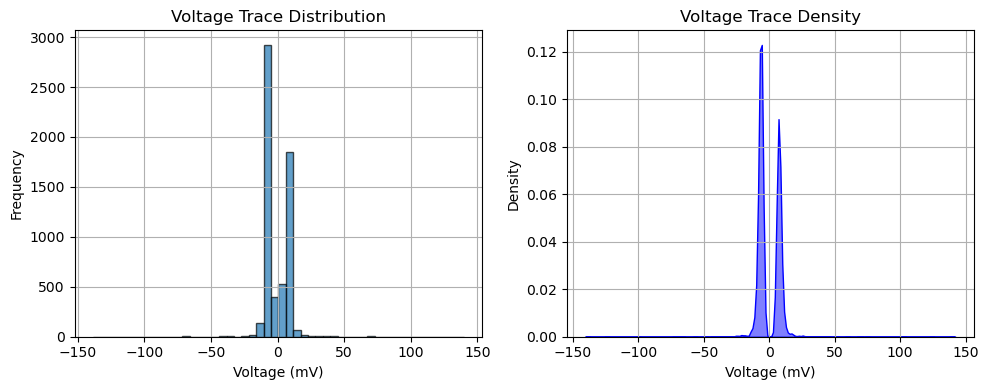

In [11]:
# to avoid warning from Seaborn internally calling a Pandas option 
# (mode.use_inf_as_na) that has been deprecated in pandas ≥ 2.1.

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot histogram on the first subplot
axes[0].hist(data, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel("Voltage (mV)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Voltage Trace Distribution")
axes[0].grid(True)

# Plot KDE on the second subplot
sns.kdeplot(data, bw_adjust=0.5, fill=True, color="b", alpha=0.5, ax=axes[1])
axes[1].set_xlabel("Voltage (mV)")
axes[1].set_ylabel("Density")
axes[1].set_title("Voltage Trace Density")
axes[1].grid(True)

# Adjust layout
plt.tight_layout()
color_adcplt.show()

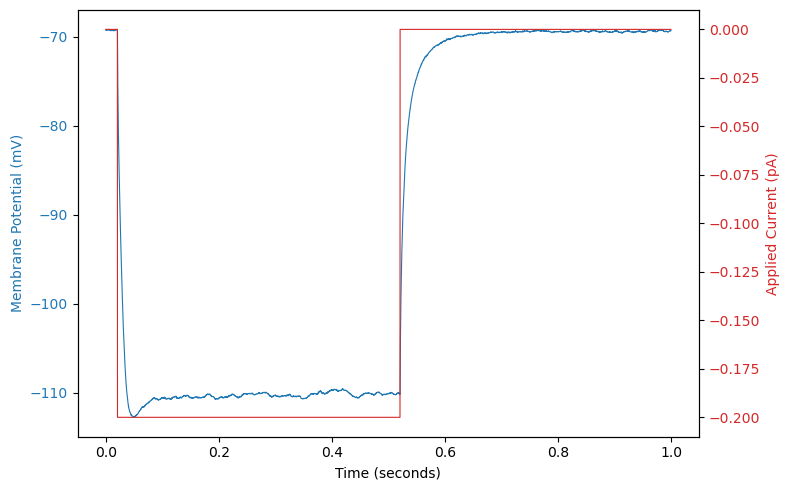

In [13]:
color_adc = "C0"
color_dac = "C3"
my_lw = 0.8

# Create the figure
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot the recorded curve (ADC) on the left axis
ax1.plot(abf.sweepX, abf.sweepY, color=color_adc, lw=my_lw, label="ADC waveform")
ax1.set_xlabel(abf.sweepLabelX)
ax1.set_ylabel(abf.sweepLabelY, color=color_adc)
ax1.tick_params(axis='y', labelcolor=color_adc)

# Create a second y-axis for the control curve (DAC)
ax2 = ax1.twinx()
ax2.plot(abf.sweepX, abf.sweepC, color=color_dac, lw=my_lw,label="DAC waveform")
ax2.set_ylabel(abf.sweepLabelC, color=color_dac)
ax2.tick_params(axis='y', labelcolor=color_dac)

# Improve the layout
fig.tight_layout()
plt.show()

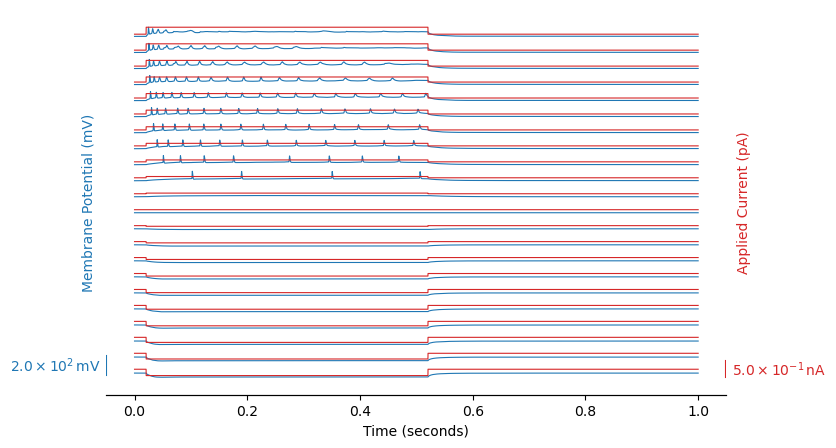

In [14]:
import pyabf
import matplotlib.pyplot as plt
import numpy as np

file_path = "records/2024_02/2024_02_06_0000.abf"
abf = pyabf.ABF(file_path)

fig, ax1 = plt.subplots(figsize=(8, 5))

n_sweeps = len(abf.sweepList)

# --- ADC scaling ---
all_adc = []
for s in abf.sweepList:
    abf.setSweep(s)
    all_adc.append(abf.sweepY)
adc_range = np.max(all_adc) - np.min(all_adc)
adc_spacing = adc_range * 1.2  

for i, s in enumerate(abf.sweepList):
    abf.setSweep(s)
    offset = i * adc_spacing
    ax1.plot(abf.sweepX, abf.sweepY + offset, color=color_adc, lw=my_lw)

ax1.set_xlabel(abf.sweepLabelX)
ax1.tick_params(axis='y', which='both', length=0)
ax1.set_yticklabels([])
ax1.set_ylabel(abf.sweepLabelY, color=color_adc)

# --- DAC scaling ---
all_dac = []
for s in abf.sweepList:
    abf.setSweep(s)
    all_dac.append(abf.sweepC)
dac_range = np.max(all_dac) - np.min(all_dac)
dac_spacing = dac_range * 1.2

ax2 = ax1.twinx()
for i, s in enumerate(abf.sweepList):
    abf.setSweep(s)
    offset = i * dac_spacing
    ax2.plot(abf.sweepX, abf.sweepC + offset, color=color_dac, lw=my_lw)

ax2.tick_params(axis='y', which='both', length=0)
ax2.set_yticklabels([])
ax2.set_ylabel(abf.sweepLabelC, color=color_dac)


# --- Helper: nice rounded scale ---
def nice_scale(value):
    exp = int(np.floor(np.log10(abs(value)))) if value != 0 else 0
    base = value / (10**exp) if value != 0 else 0
    if base <= 1:
        nice = 1
    elif base <= 2:
        nice = 2
    elif base <= 5:
        nice = 5
    else:
        nice = 10
    return nice * 10**exp

# --- Helper: LaTeX style scale label ---
def format_scale_label_latex(value, unit):
    if value == 0:
        return rf"$0\,\mathrm{{{unit}}}$"
    exp = int(np.floor(np.log10(abs(value))))
    mant = value / (10**exp)
    return rf"${mant:.1f} \times 10^{{{exp}}}\,\mathrm{{{unit}}}$"

# --- Compute scale bars ---
adc_bar = nice_scale(adc_range * 1)
dac_bar = nice_scale(dac_range * 1)

# --- Anchors below first sweep ---
y_anchor_adc = -0.5 * adc_spacing
y_anchor_dac = -0.5 * dac_spacing

x0 = abf.sweepX[0] - (abf.sweepX[-1] - abf.sweepX[0]) * 0.05
x1 = abf.sweepX[-1] + (abf.sweepX[-1] - abf.sweepX[0]) * 0.05

# --- Left (ADC) scale bar ---
ax1.plot([x0, x0], [y_anchor_adc, y_anchor_adc + adc_bar], color=color_adc, lw=1.5)
ax1.text(x0 - 0.01, y_anchor_adc + adc_bar/2,
         format_scale_label_latex(adc_bar, abf.sweepUnitsY),
         va="center", ha="right", color=color_adc)
ax1.margins(x=0)

# --- Right (DAC) scale bar ---
ax2.plot([x1, x1], [y_anchor_dac, y_anchor_dac + dac_bar], color=color_dac, lw=1.5)
ax2.text(x1 + 0.01, y_anchor_dac + dac_bar/2,
         format_scale_label_latex(dac_bar, abf.sweepUnitsC),
         va="center", ha="left", color=color_dac)

# remove box spines, keep only bottom (time axis)
for spine in ["top", "left", "right"]:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)
ax2.margins(x=0)

# keep bottom spine
ax1.spines["bottom"].set_visible(True)
plt.show()
